# Prueba Intertrimestral

**Nombre:** Ruben  
**Apellidos:**  Rodriguez Gomez

**Tiempo de la prueba:** 2 horas  
**Asignatura:** Desarrollo de Aplicaciones para la Visualización de Datos  
**Fecha:** 16 de octubre de 2025  

## Instrucciones

- Escribe **código limpio y autoexplicativo**.  
- Se pueden utilizar **los materiales de clase**.  
- Se puede utilizar **internet** para búsqueda de dudas y documentación.  
- **No se puede utilizar ningún tipo de LLM** (ChatGPT, Copilot, Gemini, etc.).  
- **No se puede utilizar mensajería instantánea**.  
- Al finalizar, **sube tu notebook a GitHub** y envía el enlace del fichero en el siguiente formulario:  
[https://forms.office.com/e/LFVwu9z6uQ](https://forms.office.com/e/LFVwu9z6uQ)


## Dataset “Life Style Data”

El dataset contiene información sobre hábitos de vida (alimentación, sueño, ejercicio, consumo de tabaco o alcohol, etc.) y medidas de salud (IMC, presión arterial, etc.) para diferentes individuos.

Puedes descargarlo del repositorio de la asignatura y un .txt con la descripción de las variables.


## Inicialización de librerías

In [78]:
import pandas as pd
import numpy as np
import sklearn.datasets
import math
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression

# Ejercicio 1 — Programación (2 puntos)

a) (0.6 pts) Crea una función imc(weight, height) que devuelva el índice de masa corporal (IMC), redondeado a dos decimales.



In [11]:
def imc(weight, height):
    imc_value = weight / (height ** 2)
    return round(imc_value, 2)

b) (0.6 pts) Crea una función saludable(imcValue) que devuelva "Saludable" si el IMC está entre 18.5 y 24.9, "Bajo peso" si es menor de 18.5, o "Sobrepeso" si es mayor de 24.9.

In [12]:
def saludable(imcValue):
    if imcValue < 18.5:
        return "Bajo peso"
    elif imcValue <= 24.9:
        return "Saludable"
    else:
        return "Sobrepeso"


c) (0.6 pts) Genera un DataFrame llamado imcData que contenga al menos 10 registros con las siguientes columnas:


*   peso (en kilogramos)

*   altura (en metros)

*   imc (calculado usando la función imc(weight, height) creada anteriormente)

Puedes generar los datos de peso y altura manualmente, mediante listas, o de forma aleatoria utilizando numpy (np.random.uniform o similar).

Añade una cuarta columna llamada categoria, cuyos valores provengan de la función saludable(imcValue).

Muestra las primeras filas del DataFrame resultante y comprueba que los tipos de datos son correctos.

In [13]:
imcData = pd.DataFrame(data = [], columns = ["peso","altura","imc","categoria"])
imcData["peso"]=[52, 60, 68, 75, 80, 90, 100, 55, 65, 85]
imcData["altura"]=[1.60, 1.70, 1.75, 1.80, 1.65, 1.72, 1.85, 1.50, 1.78, 1.68]
imcData["imc"]=[imc(imcData["peso"][i],imcData["altura"][i]) for i in range(len(imcData))]
imcData["categoria"]=[saludable(imcData["imc"][i]) for i in range(len(imcData))]

imcData.head(5)


,peso,altura,imc,categoria
0,52,1.60,20.31,Saludable
1,60,1.70,20.76,Saludable
2,68,1.75,22.20,Saludable
3,75,1.80,23.15,Saludable
4,80,1.65,29.38,Sobrepeso


In [14]:
imcData.dtypes

peso           int64
altura       float64
imc          float64
categoria     object
dtype: object

In [15]:
# Comprobar el número de NAs

imcData.isna().sum()

peso         0
altura       0
imc          0
categoria    0
dtype: int64

d) (0.2 pts) ¿Cómo podrías integrar ambas funciones dentro de una clase llamada HealthTools que calcule el IMC y clasifique automáticamente a partir de listas de pesos y alturas?

In [17]:
class HealthTools:
    def __init__(self, pesos, alturas):
        self.pesos = pesos
        self.alturas = alturas

    def imc(self, i):
        return round(self.pesos[i] / (self.alturas[i] ** 2), 2)

    def saludable(self, imcValue):
        if imcValue < 18.5:
            return "Bajo peso"
        elif imcValue <= 24.9:
            return "Saludable"
        else:
            return "Sobrepeso"

    def tipoSobrepeso(self):
        resultados = []
        for i in range(len(self.pesos)):
            imcValue = self.imc(i)
            resultados.append(self.saludable(imcValue))
        return resultados
pesos=[52, 60, 68, 75, 80, 90, 100, 55, 65, 85]
alturas=[1.60, 1.70, 1.75, 1.80, 1.65, 1.72, 1.85, 1.50, 1.78, 1.68]
prueba = HealthTools(pesos, alturas)
prueba.tipoSobrepeso()


['Saludable',
 'Saludable',
 'Saludable',
 'Saludable',
 'Sobrepeso',
 'Sobrepeso',
 'Sobrepeso',
 'Saludable',
 'Saludable',
 'Sobrepeso']

## Ejercicio 2 — Exploración y visualización (3 puntos)

a) (0.75 pts) Carga el dataset desde el fichero CSV y guárdalo en un DataFrame llamado lifeStyleData. Muestra las 5 primeras filas, el número de filas y columnas.

In [55]:
lifeStyleData = pd.read_csv("Final_data.csv")
lifeStyleData.head(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [56]:
rows=len(lifeStyleData)
columns=len(lifeStyleData.columns)
print(rows)

20000


In [57]:
print(columns)

54


b) (0.75 pts) Crea una función describeData(dataFrame) que devuelva para cada columna: tipo de dato, número de valores nulos y porcentaje de nulos.

In [58]:
def describeData(dataFrame):
    info = []
    total = len(dataFrame)
    for col in dataFrame.columns:
        tipo = dataFrame[col].dtype
        nulos = dataFrame[col].isnull().sum()
        porc_nulos = (nulos / total) * 100
        info.append([col, tipo, nulos, porc_nulos])
    return pd.DataFrame(info, columns=['Columna', 'Tipo de dato', 'Nulos', '% Nulos'])

c) (0.75 pts) Usa describeData(lifeStyleData) y comenta brevemente (2–3 líneas) qué variables parecen tener más valores faltantes.

In [59]:
describeData(lifeStyleData)

,Columna,Tipo de dato,Nulos,% Nulos
0,Age,float64,0,0.000
1,Gender,object,0,0.000
2,Weight (kg),float64,0,0.000
3,Height (m),float64,0,0.000
4,Max_BPM,float64,1,0.005
5,Avg_BPM,float64,1,0.005
6,Resting_BPM,float64,0,0.000
7,Session_Duration (hours),float64,0,0.000
8,Calories_Burned,float64,0,0.000
9,Workout_Type,object,0,0.000


Se puede observar que hay simplemente hay las siguientes variables con Nulos: 
- cholesterol_mg
- Max_BPM
- Avg_BPM

Todas estas variables tienen simplemente un valor faltante. Por lo que para proceder con un analisis coherente para el resto del examen se va a proceder a eliminar estas filas del dataset lifeStyleData con el fin de no "romper" los modelos de aprendizaje que se utilicen

In [60]:
lifeStyleData = lifeStyleData.dropna()
len(lifeStyleData)

19997

d) (0.75 pts) Realiza un gráfico que muestre las correlaciones entre variables numéricas. ¿Hay alguna correlación fuerte o inesperada?

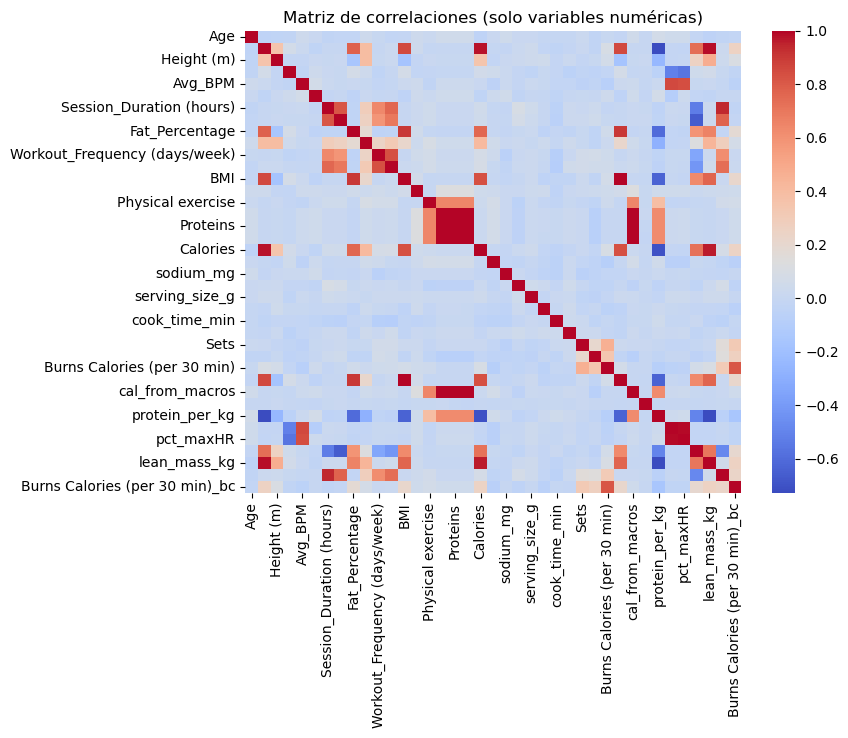

In [61]:
num_df = lifeStyleData.select_dtypes(include=['number'])
corr = num_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlaciones (solo variables numéricas)')
plt.show()

- El gráfico muestra una correlación fuerte entre el BMI y el Fat_Percentage, algo esperado porque ambos indicadores reflejan la composición corporal: a mayor cantidad de grasa, mayor es el índice de masa corporal. 
- También se observa una alta correlación entre Calories y cal_from_macros, lo cual tiene sentido, ya que las calorías totales suelen calcularse a partir de los macronutrientes (proteínas, grasas y carbohidratos).
- Las variables Burns Calories (per 30 min) y Burns Calories (per 30 min)_bc están casi perfectamente correlacionadas, lo que indica que probablemente representan la misma métrica calculada de forma ligeramente distinta.
- Se aprecia una correlación negativa entre Fat_Percentage y lean_mass_kg, coherente con el hecho de que un mayor porcentaje de grasa implica menor proporción de masa magra.

Estas son algunas de las variables, pero por lo general no hay ninguna correlacion inesperada ya que todos los factores están intuitivamente relacionados con las variables categoricas de este conjunto de datos.

Fat_Percentage, Calories, protein_per_kg

## Ejercicio 3 — Regresión básica (2 puntos)

Queremos predecir una variable de salud continua, por ejemplo bmi.

a) (0.25 pts) Define targetVar = "bmi" y selecciona 2–3 variables predictoras (por ejemplo sleepHours, activityLevel, calories). Guarda las columnas predictoras en X y la variable objetivo en y.

In [64]:
# Agregamos la variable objetivo
targetVar = lifeStyleData["BMI"]
predictors = pd.DataFrame({
    "Fat_Percentage": lifeStyleData["Fat_Percentage"],
    "Calories": lifeStyleData["Calories"],
    "protein_per_kg": lifeStyleData["protein_per_kg"]
})

X = predictors
print(X)
y = targetVar
print(y)

       Fat_Percentage  Calories  protein_per_kg
0           26.800377    1806.0        1.624789
1           27.655021    1577.0        1.514093
2           24.320821    1608.0        1.663445
3           32.813572    2657.0        0.862017
4           17.307319    1470.0        2.538153
...               ...       ...             ...
19995       27.505498    2627.0        0.954837
19996       26.180562    2477.0        0.689060
19997       23.331802    1425.0        2.105844
19998       18.985868    1276.0        2.190745
19999       24.435892    1666.0        1.494968

[19997 rows x 3 columns]
0        24.87
1        23.48
2        21.15
3        32.45
4        14.83
         ...  
19995    27.23
19996    25.20
19997    16.57
19998    16.88
19999    22.62
Name: BMI, Length: 19997, dtype: float64


b) (0.25 pts) Divide los datos en entrenamiento (70 %) y prueba (30 %).

In [65]:
# Dividir train-test
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size = 0.3, random_state = 123)

c) (0.75 pts) Entrena un modelo de regresión lineal (LinearRegression) y calcula el R² y el MSE.

In [71]:
reg = ElasticNet()
reg.fit(X_train,y_train)
predictions = reg.predict(X_test)
predictions
predictions_train = reg.predict(X_train)
# Metricas de evaluación
rmse_train = np.sqrt(mean_squared_error(y_train,predictions_train))
mse_train = mean_squared_error(y_train, predictions_train)


rmse_test = np.sqrt(mean_squared_error(y_test,predictions))
mse_test = mean_squared_error(y_test, predictions)
r2_lr = r2_score(y_test, predictions)
print("El RMSE de train del modelo es: {}".format(rmse_train))
print(f"El MSE de train del modelo es: {mse_train}")

print("")

print("El RMSE de test del modelo es: {}".format(rmse_test))
print(f"El MSE de test del modelo es: {mse_test}")
print("Regresión Lineal R²:", round(r2_lr, 3))


El RMSE de train del modelo es: 2.4404931193296227
El MSE de train del modelo es: 5.956006665495232

El RMSE de test del modelo es: 2.4348572725326165
El MSE de test del modelo es: 5.928529937604973
Regresión Lineal R²: 0.867


d) (0.75 pts) Entrena un RandomForestRegressor con los mismos datos y compara resultados. ¿Cuál tiene mejor rendimiento?

In [72]:
rf = RandomForestRegressor().fit(X_train, y_train)

rf = Pipeline(steps=[
  ('scaler', StandardScaler()),
  ("rf", RandomForestRegressor()),
])

rf = rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
predictions
predictions_train = rf.predict(X_train)
# Metricas de evaluación
rmse_train = np.sqrt(mean_squared_error(y_train,predictions_train))
mse_train = mean_squared_error(y_train, predictions_train)


rmse_test = np.sqrt(mean_squared_error(y_test,predictions))
mse_test = mean_squared_error(y_test, predictions)
r2_rf = r2_score(y_test, predictions)

print("El RMSE de train del modelo es: {}".format(rmse_train))
print(f"El MSE de train del modelo es: {mse_train}")

print("")

print("El RMSE de test del modelo es: {}".format(rmse_test))
print(f"El MSE de test del modelo es: {mse_test}")
print("Regresión Lineal R²:", round(r2_rf, 3))

El RMSE de train del modelo es: 0.7627613670646779
El MSE de train del modelo es: 0.5818049030863762

El RMSE de test del modelo es: 2.0015817271081717
El MSE de test del modelo es: 4.006329410293331
Regresión Lineal R²: 0.91


Se puede apreciar que el RandomForest es mucho mas preciso. A parte de llevar menos errores consigo (lo cual tiene mucho que ver con que el R2 sea mejor en el RandomForest que en la regression linear)

## Ejercicio 4 — Clasificación sencilla (2 puntos)

Crea una nueva variable binaria que indique si el IMC está dentro del rango saludable.

a) (0.25 pts) Crea una nueva columna bmiHealthy donde el valor sea 1 si bmi está entre 18.5 y 24.9, y 0 en caso contrario.

In [73]:
lifeStyleData["bmiHealthy"] = 0
lifeStyleData.loc[(lifeStyleData["BMI"] >= 18.5) & (lifeStyleData["BMI"] <= 24.9), "bmiHealthy"] = 1


b) (0.75 pts) Entrena un modelo de regresión logística (LogisticRegression) para predecir bmiHealthy usando algunas variables de estilo de vida (por ejemplo sleepHours, activityLevel, calories).

Classification report
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      3802
           1       0.43      0.35      0.39      2198

    accuracy                           0.59      6000
   macro avg       0.55      0.54      0.54      6000
weighted avg       0.58      0.59      0.58      6000

Confusion matrix
[[2798 1004]
 [1429  769]]


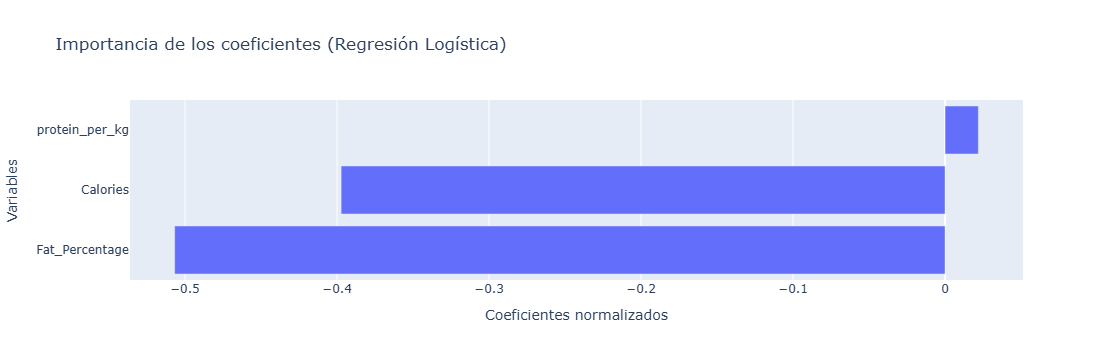

In [81]:
X = pd.DataFrame({
    "Fat_Percentage": lifeStyleData["Fat_Percentage"],
    "Calories": lifeStyleData["Calories"],
    "protein_per_kg": lifeStyleData["protein_per_kg"]
})

y = lifeStyleData["bmiHealthy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf_log = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('glm', LogisticRegression(max_iter=10000, tol=0.1))
])

clf_log.fit(X_train, y_train)
predictions = clf_log.predict(X_test)

print("Classification report")
print(classification_report(y_test, predictions))
print("Confusion matrix")
print(confusion_matrix(y_test, predictions))

lmc = clf_log.named_steps['glm'].coef_[0]
objects = X.columns

fig = go.Figure()
fig.add_trace(go.Bar(x=lmc, y=objects, name="Coeficientes", orientation='h'))
fig.update_layout(title="Importancia de los coeficientes (Regresión Logística)",
                  xaxis_title="Coeficientes normalizados", yaxis_title="Variables")
fig.show()


c) (0.25 pts) Calcula la exactitud (accuracy) del modelo y muestra la matriz de confusión.


In [79]:
accuracy = accuracy_score(y_test, predictions)
print("Exactitud (accuracy):", round(accuracy, 3))

print("Matriz de confusión:")
print(confusion_matrix(y_test, predictions))

Exactitud (accuracy): 0.595
Matriz de confusión:
[[2798 1004]
 [1429  769]]


d) (0.75 pts) Explica qué variable parece influir más según el modelo.

Según los coeficientes del modelo de regresión logística, la variable con el valor absoluto más alto es la que tiene mayor influencia en la probabilidad de que el IMC esté dentro del rango saludable. Si, por ejemplo, el coeficiente más alto corresponde a activityLevel, esto indicaría que el nivel de actividad física es el factor que más contribuye a mantener un IMC saludable. En cambio, si el coeficiente mayor pertenece a Calories o protein_per_kg, el modelo estaría señalando que la ingesta calórica o el consumo de proteínas por kilo tienen un papel más determinante. En resumen, la variable con el coeficiente más alto en valor absoluto es la de mayor peso en la predicción.
En este caso de la regresion logistica, seria "Fat percentage" que esta relacionado muy negativamente con bmiHealthy, lo cual tiene mucho sentido

## Ejercicio 5 — Conclusión (1 punto)

En un máximo de 300 palabras, resume:

*   Qué hábitos parecen tener mayor relación con el estado de salud.

*   Qué modelo fue más eficaz y por qué.

*   Qué podrías mejorar si tuvieras más tiempo o datos.




1) Esta claro que con las variables estudiadas, con el fin de tener un BMI optimo y por lo tanto un estado saludable es muy recomendable reducir el numero de calorias y de grasa coirporal de la persona. De este modo si al mismo tiempo con una dieta sostenible, se consigue construir musculo mediante la ingesta moderada de proteinas, se conseguira no solo reducir a un peso que sea adecuado para la persona en comun pero tambien conseguira construir musculo.
   
2) El modelo más eficaz fue el RandomForest en este caso porque es un modelo bastante mas complejo que tiene en cuenta las mejores iteraciones de todas las variables con el fin de encontrar el mejor peso y por loo tanto, las mejores predicciones

3) Es relevante considerar las siguientes limitaciones y las mejoras que se tendrían que hacer si se tuviese mas tiempo:

- Variables Omitidas: Hay variables importantes que no se han incluido en el análisis, lo que podría afectar los resultados y la precisión de las predicciones. Por lo que, en el futuro se recomienda estudiar por ejemplo el BMI pero con otras variables que a lo mejor no tengan tanta relacion.

- Causalidad vs Correlación: La identificación de relaciones entre variables y las ventas no implica causalidad, por lo que se recomienda un enfoque cauteloso en la interpretación de los resultados. Ademas de conseguir mas datos actuales